In [1]:
import networkx as nx
import matplotlib.pyplot as plt


In [4]:
def nearest_neighbor_tsp(cost):
  numNodes = len(cost)
  visited=[False]*numNodes
  path=[0]
  visited[0] = True
  total_cost=0
  current = 0
  for _ in range(numNodes-1):
    next_city=min((j for j in range(numNodes) if not visited[j]), key=lambda j: cost[current][j])
    total_cost += cost[current][next_city]
    visited[next_city] = True
    path.append(next_city)
    current = next_city
  total_cost += cost[current][0]
  path.append(0)
  return total_cost, path



In [5]:
def plot_tsp(cost, path):
  G = nx.Graph()
  numNodes = len(cost)
  pos = nx.circular_layout(range(numNodes))
  for i in range(numNodes):
    for j in range(i + 1, numNodes):
      G.add_edge(i, j, weight=cost[i][j])
  plt.figure(figsize=(6, 6))
  nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1000, font_size=12)
  path_edges = list(zip(path, path[1:]))
  nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2)
  plt.title("TSP Solution using Nearest Neighbor Heuristic")
  plt.show()





Approximate Minimum Cost:80
Path Taken: [0, 1, 3, 2, 0]


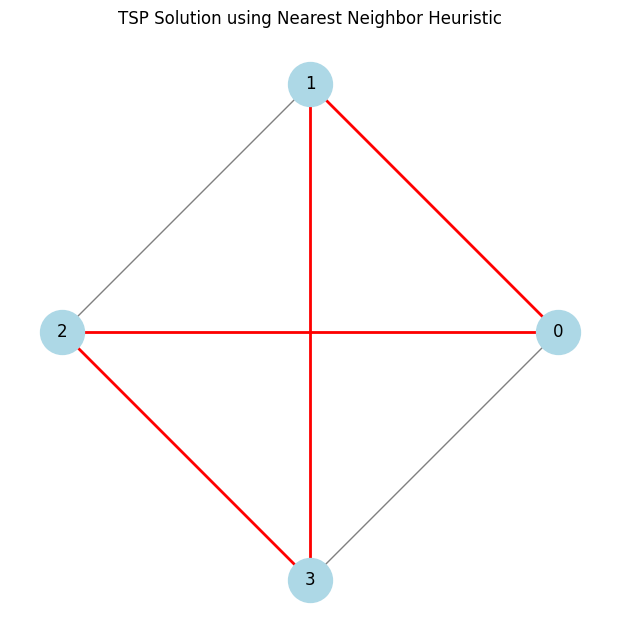

In [7]:
if __name__ == "__main__":
  cost = [
      [0,10,15,20],
      [10,0,35,25],
      [15,35,0,30],
      [20,25,30,0]
  ]
  res_cost, res_path = nearest_neighbor_tsp(cost)
  print(f"Approximate Minimum Cost:{res_cost}")
  print(f"Path Taken: {res_path}")
  plot_tsp(cost,res_path)